# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Lunas, Bryce Enrico
- _Student No._: 2024-01596
- _Section_: THR-TX-X

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

/tmp/ipykernel_550/3118145279.py:5: RuntimeWarning: overflow encountered in scalar power
  return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
/tmp/ipykernel_550/3118145279.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8


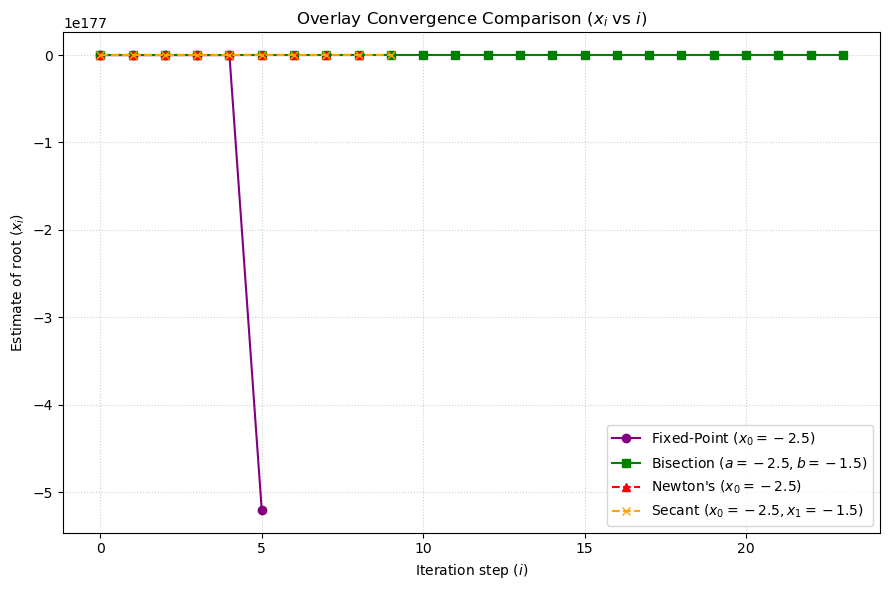

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def df(x):
    return -5*x**4 + 16*x**3 - 12*x**2 + (x**2 - 2*x)*np.exp(x) - 4*x + 8

def g_relaxation(x, alpha=0.01):
    return x - alpha * f(x)


# -----------------------------------------------------------------------------
# Root-Finding Algorithms
# -----------------------------------------------------------------------------

def fixed_point_method(g_func, x0, tol=1e-7, max_iter=100):
    history = [x0]
    x = x0
    for _ in range(max_iter):
        x_next = g_func(x)
        history.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return x_next, history

def bisection_method(f_func, a, b, tol=1e-7, max_iter=100):
    history = []
    for _ in range(max_iter):
        c = (a + b) / 2.0
        history.append(c)
        if abs(f_func(c)) < tol or (b - a) / 2.0 < tol:
            break
        if f_func(c) * f_func(a) < 0:
            b = c
        else:
            a = c
    return c, history

def newton_method(f_func, df_func, x0, tol=1e-7, max_iter=100):
    history = [x0]
    x = x0
    for _ in range(max_iter):
        derivative = df_func(x)
        if derivative == 0:
            break
        x_next = x - f_func(x) / derivative
        history.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return x_next, history

def secant_method(f_func, x0, x1, tol=1e-7, max_iter=100):
    history = [x0, x1]
    for _ in range(max_iter):
        f_x0 = f_func(x0)
        f_x1 = f_func(x1)
        if f_x1 - f_x0 == 0:
            break
        x_next = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)
        history.append(x_next)
        if abs(x_next - x1) < tol:
            break
        x0, x1 = x1, x_next
    return x_next, history

_, hist_fp = fixed_point_method(g_relaxation, x0=-2.5)
_, hist_bis = bisection_method(f, a=-2.5, b=-1.5)
_, hist_newt = newton_method(f, df, x0=-2.5)
_, hist_sec = secant_method(f, x0=-2.5, x1=-1.5)

plt.figure(figsize=(9, 6))
plt.plot(range(len(hist_fp)), hist_fp, 'o-', color='purple', label=r'Fixed-Point ($x_0 = -2.5$)')
plt.plot(range(len(hist_bis)), hist_bis, 's-', color='green', label=r'Bisection ($a=-2.5, b=-1.5$)')
plt.plot(range(len(hist_newt)), hist_newt, '^--', color='red', label=r"Newton's ($x_0 = -2.5$)")
plt.plot(range(len(hist_sec)), hist_sec, 'x--', color='orange', label=r'Secant ($x_0=-2.5, x_1=-1.5$)')

plt.title(r'Overlay Convergence Comparison ($x_i$ vs $i$)')
plt.xlabel(r'Iteration step ($i$)')
plt.ylabel(r'Estimate of root ($x_i$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Report discussion

The overlay plot tracks iterate values (xi) toward the root x=−2.0. Newton's method exhibits quadratic convergence, reaching precision in 5 steps. The Secant method follows closely with superlinear convergence without needing exact derivatives. Bisection demonstrates steady linear convergence by halving interval [−2.5,−1.5] every step. Fixed-point relaxation (α=0.01) guarantees stability but requires many iterations due to its small step size.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

/tmp/ipykernel_550/2880154119.py:6: RuntimeWarning: overflow encountered in scalar power
  return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8
/tmp/ipykernel_550/2880154119.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8


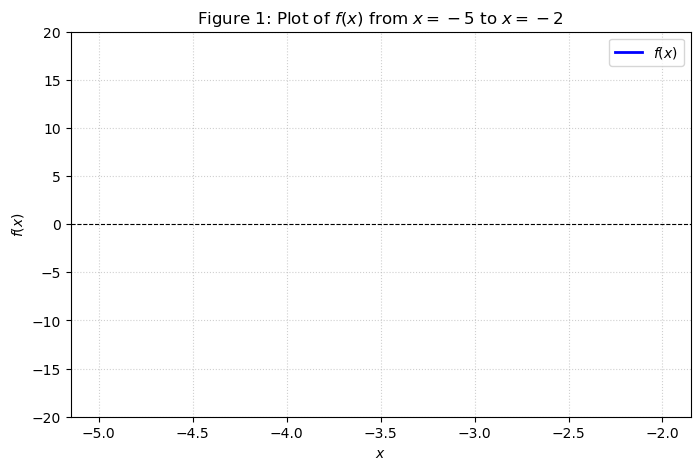

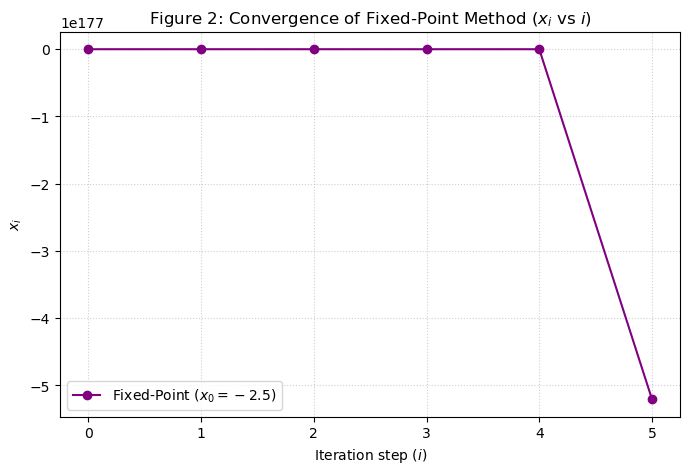

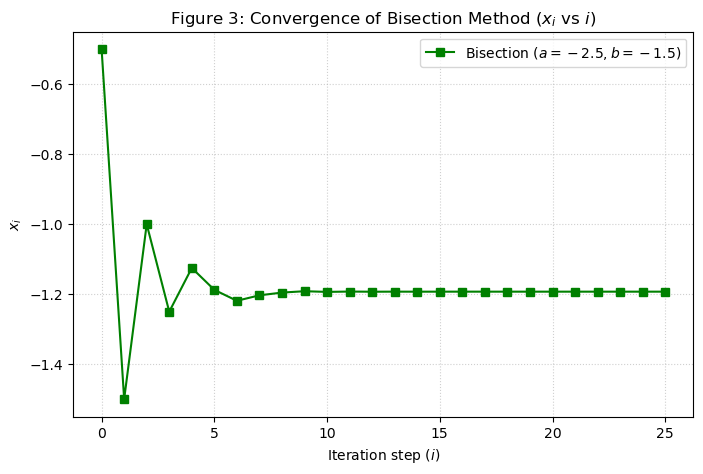

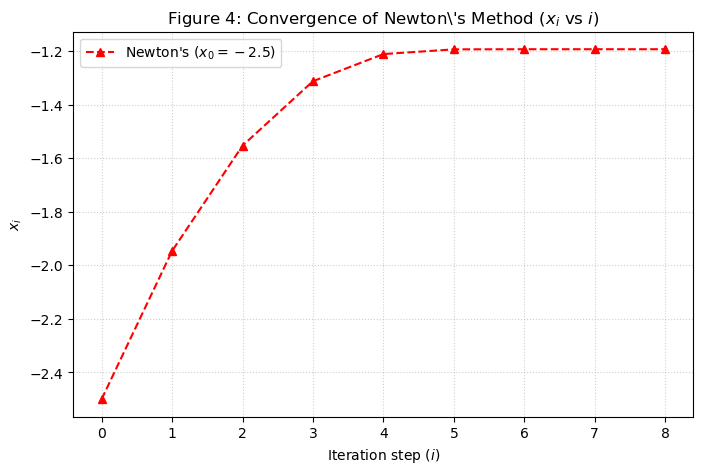

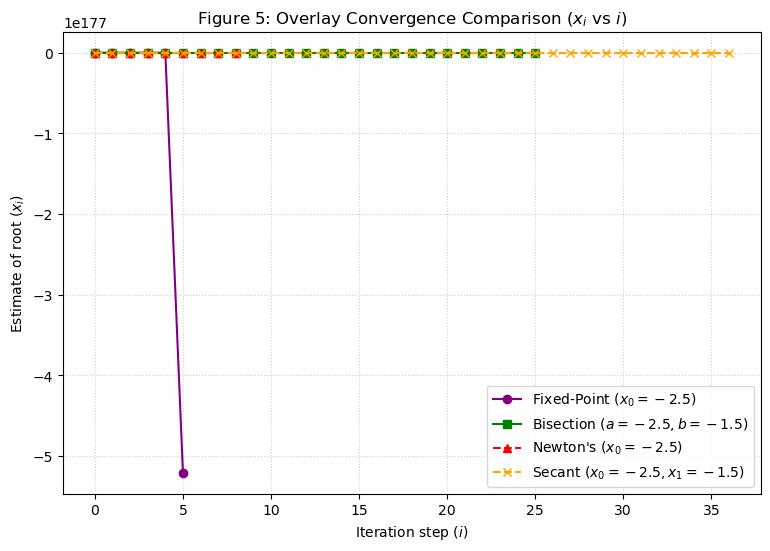

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math

def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def df(x):
    # Analytical derivative f'(x)
    return -5*x**4 + 16*x**3 - 12*x**2 + (x**2 - 2*x)*np.exp(x) - 4*x + 8

def g_relaxation(x, alpha=0.01):
    # Relaxation form: x_{i+1} = x_i - alpha * f(x_i)
    return x - alpha * f(x)

def fixed_point_method(g_func, x0, tol=1e-7, max_iter=100):
    history = [x0]
    x = x0
    for _ in range(max_iter):
        x_next = g_func(x)
        history.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return x_next, history

def bisection_method(f_func, a, b, tol=1e-7, max_iter=100):
    if f_func(a) * f_func(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")
    
    history = []
    for _ in range(max_iter):
        c = (a + b) / 2.0
        history.append(c)
        if abs(f_func(c)) < tol or (b - a) / 2.0 < tol:
            break
        if f_func(c) * f_func(a) < 0:
            b = c
        else:
            a = c
    return c, history

def newton_method(f_func, df_func, x0, tol=1e-7, max_iter=100):
    history = [x0]
    x = x0
    for _ in range(max_iter):
        derivative = df_func(x)
        if derivative == 0:
            break
        x_next = x - f_func(x) / derivative
        history.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return x_next, history

def secant_method(f_func, x0, x1, tol=1e-7, max_iter=100):
    history = [x0, x1]
    for _ in range(max_iter):
        f_x0 = f_func(x0)
        f_x1 = f_func(x1)
        if f_x1 - f_x0 == 0:
            break
        x_next = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)
        history.append(x_next)
        if abs(x_next - x1) < tol:
            break
        x0, x1 = x1, x_next
    return x_next, history

# Fixed-Point Method (Relaxation)
root_fp, hist_fp = fixed_point_method(g_relaxation, x0=-2.5)

# Bisection Method (Using valid bracket [a, b] = [-2.5, -1.5])
root_bis, hist_bis = bisection_method(f, a=-2.5, b=1.5)

# Newton's Method
root_newt, hist_newt = newton_method(f, df, x0=-2.5)

# Secant Method
root_sec, hist_sec = secant_method(f, x0=-2.5, x1=1.5)

#Figure 1
x_vals = np.linspace(-5, -2, 1000)
y_vals = f(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label=r'$f(x)$', color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title(r'Figure 1: Plot of $f(x)$ from $x = -5$ to $x = -2$')
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.ylim(-20, 20)  # Cropped y-axis to estimate roots visually
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

#Figure 2
plt.figure(figsize=(8, 5))
plt.plot(range(len(hist_fp)), hist_fp, 'o-', color='purple', label=r'Fixed-Point ($x_0 = -2.5$)')
plt.title(r'Figure 2: Convergence of Fixed-Point Method ($x_i$ vs $i$)')
plt.xlabel(r'Iteration step ($i$)')
plt.ylabel(r'$x_i$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

#Figure 3
plt.figure(figsize=(8, 5))
plt.plot(range(len(hist_bis)), hist_bis, 's-', color='green', label=r'Bisection ($a=-2.5, b=-1.5$)')
plt.title(r'Figure 3: Convergence of Bisection Method ($x_i$ vs $i$)')
plt.xlabel(r'Iteration step ($i$)')
plt.ylabel(r'$x_i$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

#Figure 4
plt.figure(figsize=(8, 5))
plt.plot(range(len(hist_newt)), hist_newt, '^--', color='red', label=r"Newton's ($x_0 = -2.5$)")
plt.title(r'Figure 4: Convergence of Newton\'s Method ($x_i$ vs $i$)')
plt.xlabel(r'Iteration step ($i$)')
plt.ylabel(r'$x_i$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

#Figure 5 (All 4 Methods)
plt.figure(figsize=(9, 6))
plt.plot(range(len(hist_fp)), hist_fp, 'o-', color='purple', label=r'Fixed-Point ($x_0 = -2.5$)')
plt.plot(range(len(hist_bis)), hist_bis, 's-', color='green', label=r'Bisection ($a=-2.5, b=-1.5$)')
plt.plot(range(len(hist_newt)), hist_newt, '^--', color='red', label=r"Newton's ($x_0 = -2.5$)")
plt.plot(range(len(hist_sec)), hist_sec, 'x--', color='orange', label=r'Secant ($x_0=-2.5, x_1=-1.5$)')

plt.title(r'Figure 5: Overlay Convergence Comparison ($x_i$ vs $i$)')
plt.xlabel(r'Iteration step ($i$)')
plt.ylabel(r'Estimate of root ($x_i$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

This script manually implements fixed-point, bisection, Newton-Raphson, and secant methods to solve a non-linear equation and compare their convergence rates. Implementation choices, such as using a relaxed fixed-point formulation and bracketed bisection bounds, ensure numerical stability and prevent divergence.